#**Introducción**

###El objetivo de este proyecto es el poder comprender la evasión de clientes en la empresa Telecom X. Por tanto para eso es necesario este analisis, dado que la evasion pasa cuando un cliente decide cancelar el servicio contratado con la empresa

###Lo que a la larga representa una pardida directa de ingresos y puede afectar la estabilidad del negocio. Asi que el poder identificar los factores que influyen es vital para poder diseñar estrategias que permitan mejorar la retencio de clientes.


#📌 Extracción

###1 - Extracción de datos

In [323]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [324]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [325]:
datos = pd.read_json('/content/drive/MyDrive/Colab Notebooks/TelecomX_Data.json')

### 2 - Conoce el conjunto de datos

In [326]:
datos.shape

(7267, 6)

In [327]:
datos.dtypes

,0
customerID,object
Churn,object
customer,object
phone,object
internet,object
account,object


In [328]:
datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerID  7267 non-null   object
 1   Churn       7267 non-null   object
 2   customer    7267 non-null   object
 3   phone       7267 non-null   object
 4   internet    7267 non-null   object
 5   account     7267 non-null   object
dtypes: object(6)
memory usage: 340.8+ KB


In [329]:
datos.columns

Index(['customerID', 'Churn', 'customer', 'phone', 'internet', 'account'], dtype='object')

In [330]:
datos.head()

,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


#🔧 Transformación

##Limpieza y Tratamiento de Datos

###En esta parte del proyecto basicamente, se paso de tener datos "sucios" y desordenados a tener una tabla limpia y lista para analizar. En este caso al usar value_counts(), se descubrió que había 224 celdas con un espacio vacío (' ').

###Por tanto esos espacion fueron convertidos en valores nulos reales (pd.NA) y luego se borraron esas filas con dropna(). Asegurando asi de trabajar solo con informacion completa.

* Ademas que se aplanaron las columnas, pues eran datos que estaban guardados como en una lista dentro de una sola celda. Por eso se uso pd.json_normalize

###1 - Comprobación de incoherencias en los datos

In [331]:
#OJO aqui con las '' vacias
pd.unique(datos['Churn'])

array(['No', 'Yes', ''], dtype=object)

In [332]:
datos['Churn'].value_counts()

,count
Churn,
No,5174
Yes,1869
,224


In [333]:
print(datos['Churn'].isnull().sum())

0


In [334]:
datos['Churn'].unique()

array(['No', 'Yes', ''], dtype=object)

In [335]:
print("--- Valores que son nulos ---")
print(datos.isnull().sum())

--- Valores que son nulos ---
customerID    0
Churn         0
customer      0
phone         0
internet      0
account       0
dtype: int64


###2 - Manejo de inconsistencias

* Ahora que has identificado las inconsistencias, es momento de aplicar las correcciones necesarias. Ajusta los datos para asegurarte de que estén completos y coherentes, preparándolos para las siguientes etapas del análisis.

In [336]:
#El problemita que habia con las '' vacias es quitado
datos['Churn'] = datos['Churn'].replace('', pd.NA)
datos = datos.dropna(subset=['Churn'])

In [337]:
import ast

In [378]:
import warnings
warnings.filterwarnings('ignore')

In [338]:
# Verificar que ahora sí son dict
print(type(datos['customer'][0]))

<class 'dict'>


In [339]:
# Aplanar las columnas porque estan ANIDADAS
customer_df = pd.json_normalize(datos['customer'])
phone_df    = pd.json_normalize(datos['phone'])
internet_df = pd.json_normalize(datos['internet'])
account_df  = pd.json_normalize(datos['account'])

In [340]:
df = pd.concat([datos[['customerID', 'Churn']], customer_df, phone_df, internet_df, account_df],axis=1)

In [341]:
df.duplicated().sum()

np.int64(0)

In [342]:
df.isnull().sum()

,0
customerID,213
Churn,213
gender,213
SeniorCitizen,213
Partner,213
Dependents,213
tenure,213
PhoneService,213
MultipleLines,213
InternetService,213


In [343]:
df

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total
0,0002-ORFBO,No,Female,0.0,Yes,Yes,9.0,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.60,593.3
1,0003-MKNFE,No,Male,0.0,No,No,9.0,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.90,542.4
2,0004-TLHLJ,Yes,Male,0.0,No,No,4.0,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.90,280.85
3,0011-IGKFF,Yes,Male,1.0,Yes,No,13.0,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.00,1237.85
4,0013-EXCHZ,Yes,Female,1.0,Yes,No,3.0,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.90,267.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6980,NaN,NaN,Female,1.0,No,No,1.0,No,No phone service,DSL,...,No,No,No,No,No,Month-to-month,No,Mailed check,25.05,25.05
7002,NaN,NaN,Female,0.0,No,No,15.0,Yes,No,DSL,...,Yes,Yes,Yes,Yes,Yes,Month-to-month,No,Mailed check,84.45,1287.85
7009,NaN,NaN,Male,0.0,No,No,32.0,Yes,Yes,Fiber optic,...,No,No,No,No,Yes,Month-to-month,Yes,Bank transfer (automatic),85.65,2664.3
7016,NaN,NaN,Male,0.0,Yes,No,69.0,No,No phone service,DSL,...,Yes,Yes,Yes,Yes,Yes,One year,Yes,Credit card (automatic),60.80,4263.4


### 3 - Columna de cuentas diarias

* Ahora que los datos están limpios, es momento de crear la columna "Cuentas_Diarias". Utiliza la facturación mensual para calcular el valor diario, proporcionando una visión más detallada del comportamiento de los clientes a lo largo del tiempo.

* 📌 Esta columna te ayudará a profundizar en el análisis y a obtener información valiosa para las siguientes etapas.

In [344]:
df.columns

Index(['customerID', 'Churn', 'gender', 'SeniorCitizen', 'Partner',
       'Dependents', 'tenure', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'Charges.Monthly',
       'Charges.Total'],
      dtype='object')

In [345]:
df['Charges.Monthly'] = pd.to_numeric(df['Charges.Monthly'], errors='coerce')
df['Charges.Total'] = pd.to_numeric(df['Charges.Total'], errors='coerce')

In [346]:
# Crear columna de cuentas diarias
df['Cuentas_Diarias'] = (df['Charges.Monthly'] / 30).round(2)

In [347]:
print(df[['Charges.Monthly', 'Cuentas_Diarias']].head())

   Charges.Monthly  Cuentas_Diarias
0             65.6             2.19
1             59.9             2.00
2             73.9             2.46
3             98.0             3.27
4             83.9             2.80


In [348]:
df['Cuentas_Diarias'].head()

,Cuentas_Diarias
0,2.19
1,2.00
2,2.46
3,3.27
4,2.80


### 4 - Estandarización y transformación de datos

####La estandarización y transformación de datos es una etapa opcional, pero altamente recomendada, ya que busca hacer que la información sea más consistente, comprensible y adecuada para el análisis.

* Durante esta fase, por ejemplo, puedes convertir valores textuales como "Sí" y "No" en valores binarios (1 y 0), lo que facilita el procesamiento matemático y la aplicación de modelos analíticos.

* Además, traducir o renombrar columnas y datos hace que la información sea más accesible y fácil de entender, especialmente cuando se trabaja con fuentes externas o términos técnicos.

* Aunque no es un paso obligatorio, puede mejorar significativamente la claridad y comunicación de los resultados, facilitando la interpretación y evitando confusiones, especialmente al compartir información con stakeholders no técnicos.

In [379]:
#Para convertir en Si y No a binarios
df.replace({'Yes': 1, 'No': 0}, inplace=True)

In [350]:
df['Churn'] = df['Churn'].replace({'Yes': 1, 'No': 0})

In [351]:
#Se pide que se renombren algunas columnas
df.rename(columns={'customerID': 'ClienteID','Charges.Monthly': 'CargoMensual','Charges.Total': 'CargoTotal', 'tenure': 'MesesCliente'}, inplace=True)

In [352]:
df.head()

,ClienteID,Churn,gender,SeniorCitizen,Partner,Dependents,MesesCliente,PhoneService,MultipleLines,InternetService,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,CargoMensual,CargoTotal,Cuentas_Diarias
0,0002-ORFBO,0.0,Female,0.0,1.0,1.0,9.0,1.0,0,DSL,...,0,1,1,0,One year,1.0,Mailed check,65.6,593.30,2.19
1,0003-MKNFE,0.0,Male,0.0,0.0,0.0,9.0,1.0,1,DSL,...,0,0,0,1,Month-to-month,0.0,Mailed check,59.9,542.40,2.00
2,0004-TLHLJ,1.0,Male,0.0,0.0,0.0,4.0,1.0,0,Fiber optic,...,1,0,0,0,Month-to-month,1.0,Electronic check,73.9,280.85,2.46
3,0011-IGKFF,1.0,Male,1.0,1.0,0.0,13.0,1.0,0,Fiber optic,...,1,0,1,1,Month-to-month,1.0,Electronic check,98.0,1237.85,3.27
4,0013-EXCHZ,1.0,Female,1.0,1.0,0.0,3.0,1.0,0,Fiber optic,...,0,1,1,0,Month-to-month,1.0,Mailed check,83.9,267.40,2.80


In [353]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7256 entries, 0 to 7031
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ClienteID         7043 non-null   object 
 1   Churn             7043 non-null   float64
 2   gender            7043 non-null   object 
 3   SeniorCitizen     7043 non-null   float64
 4   Partner           7043 non-null   float64
 5   Dependents        7043 non-null   float64
 6   MesesCliente      7043 non-null   float64
 7   PhoneService      7043 non-null   float64
 8   MultipleLines     7043 non-null   object 
 9   InternetService   7043 non-null   object 
 10  OnlineSecurity    7043 non-null   object 
 11  OnlineBackup      7043 non-null   object 
 12  DeviceProtection  7043 non-null   object 
 13  TechSupport       7043 non-null   object 
 14  StreamingTV       7043 non-null   object 
 15  StreamingMovies   7043 non-null   object 
 16  Contract          7043 non-null   object 
 17  

#📊 Carga y análisis

##Analisis Exploratorio de Datos
###Dentro de los hallazgos se identifico cuánta gente se estaba yendo. Siendo un grupo grande de mas de 7,000 clientes, la gran mayoría decide quedarse, pero hay un grupo considerable de casi 1,900 personas que cancelaron el servicio.

###Y esto nos da una señal de alerta para entender qué está pasando con ese porcentaje que abandona la empresa. Al revisar el tipo de contrato, vemos que los clientes que pagan mes a mes son los que más se van, probablemente porque no tienen un compromiso a largo plazo.

* En cambio, quienes firman por uno o dos años suelen ser mucho más fieles y estables. Y tambien influye como pagan los clientes. Se descubrio que las personas que usan el cheque electrónico cancelan mucho más que aquellas que tienen sus pagos automatizados con tarjeta o transferencia.



### 1 - Análisis Descriptivo

* Para comenzar, realiza un análisis descriptivo de los datos, calculando métricas como media, mediana, desviación estándar y otras medidas que ayuden a comprender mejor la distribución y el comportamiento de los clientes.

In [354]:
df.describe()

,Churn,SeniorCitizen,Partner,Dependents,MesesCliente,PhoneService,PaperlessBilling,CargoMensual,CargoTotal,Cuentas_Diarias
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7032.000000,7043.000000
mean,0.265370,0.162147,0.483033,0.299588,32.371149,0.903166,0.592219,64.761692,2283.300441,2.158675
std,0.441561,0.368612,0.499748,0.458110,24.559481,0.295752,0.491457,30.090047,2266.771362,1.003088
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,18.250000,18.800000,0.610000
25%,0.000000,0.000000,0.000000,0.000000,9.000000,1.000000,0.000000,35.500000,401.450000,1.180000
50%,0.000000,0.000000,0.000000,0.000000,29.000000,1.000000,1.000000,70.350000,1397.475000,2.340000
75%,1.000000,0.000000,1.000000,1.000000,55.000000,1.000000,1.000000,89.850000,3794.737500,2.990000
max,1.000000,1.000000,1.000000,1.000000,72.000000,1.000000,1.000000,118.750000,8684.800000,3.960000


In [355]:
print("Media:")
print(df.mean(numeric_only=True))

Media:
Churn                  0.265370
SeniorCitizen          0.162147
Partner                0.483033
Dependents             0.299588
MesesCliente          32.371149
PhoneService           0.903166
PaperlessBilling       0.592219
CargoMensual          64.761692
CargoTotal          2283.300441
Cuentas_Diarias        2.158675
dtype: float64


In [356]:
#Vemos cuantos clientes se quedan y cuantos se van
df['Churn'].value_counts()

,count
Churn,
0.0,5174
1.0,1869


In [357]:
print("Mediana:")
print(df.median(numeric_only=True))

Mediana:
Churn                  0.000
SeniorCitizen          0.000
Partner                0.000
Dependents             0.000
MesesCliente          29.000
PhoneService           1.000
PaperlessBilling       1.000
CargoMensual          70.350
CargoTotal          1397.475
Cuentas_Diarias        2.340
dtype: float64


In [358]:
#Este es el promedio de gasto mensual OJO
df['CargoMensual'].mean()

np.float64(64.76169246059918)

In [359]:
print("Desviación estandar:")
print(df.std(numeric_only=True))

Desviación estandar:
Churn                  0.441561
SeniorCitizen          0.368612
Partner                0.499748
Dependents             0.458110
MesesCliente          24.559481
PhoneService           0.295752
PaperlessBilling       0.491457
CargoMensual          30.090047
CargoTotal          2266.771362
Cuentas_Diarias        1.003088
dtype: float64


### 2 - Distribución de evasión

* En este paso, el objetivo es comprender cómo está distribuida la variable "churn" (evasión) entre los clientes. Utiliza gráficos para visualizar la proporción de clientes que permanecieron y los que se dieron de baja.

In [360]:
import matplotlib.pyplot as plt

In [361]:
churn_counts = df['Churn'].value_counts()

print("Distribucion de Churn:")
print(churn_counts)

Distribucion de Churn:
Churn
0.0    5174
1.0    1869
Name: count, dtype: int64


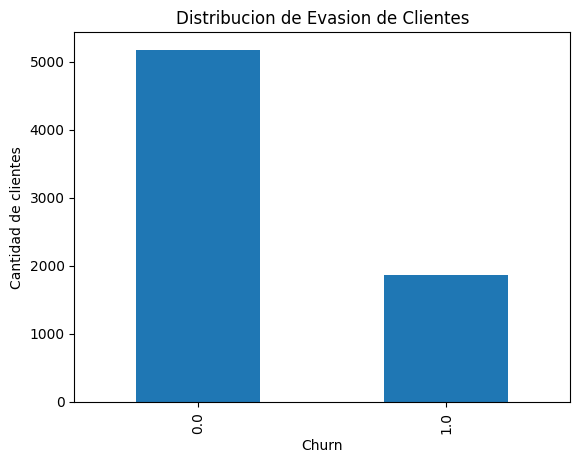

In [362]:
#Si es 0 significa que se queda el cliente
#En cambio si es 1 es que cancela el sevicio

churn_counts.plot(kind='bar')
plt.title("Distribucion de Evasion de Clientes")
plt.ylabel("Cantidad de clientes")

plt.show()

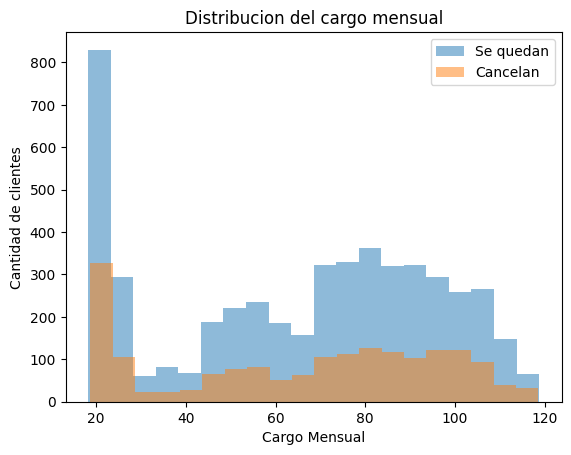

In [363]:
#El cargo mensual vs churn
#Estos son los clientes que se quedaron
df[df['Churn'] == 0]['CargoMensual'].plot(kind='hist', alpha=0.5, bins=20)

#Y aqui los clientes que cancelaron
df[df['Churn'] == 1]['CargoMensual'].plot(kind='hist', alpha=0.5, bins=20)

plt.title("Distribucion del cargo mensual")
plt.xlabel("Cargo Mensual")
plt.ylabel("Cantidad de clientes")

plt.legend(["Se quedan", "Cancelan"])

plt.show()

### 3 - Recuento de evasión por variables categóricas

* Ahora, exploraremos cómo se distribuye la evasión según variables categóricas, como género, tipo de contrato, método de pago, entre otras. Este análisis puede revelar patrones interesantes, por ejemplo, si los clientes de ciertos perfiles tienen una mayor tendencia a cancelar el servicio, lo que ayudará a orientar acciones estratégicas.

In [364]:
import matplotlib.pyplot as plt

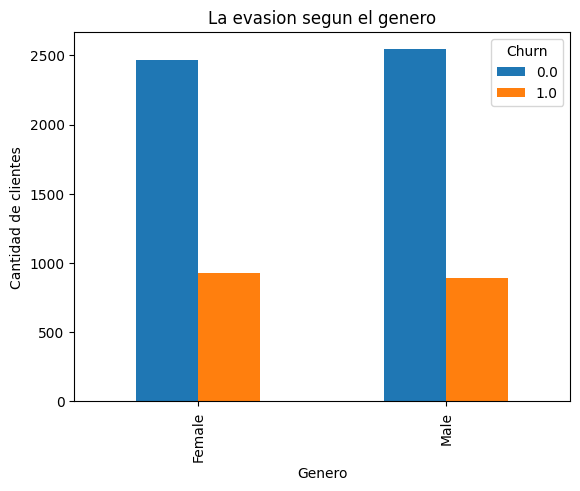

In [365]:
#Aqui es con el genero
#El grafico muestra la cantidad de clientes que permanecieron (0) y los que cancelaron el servicio (1) segun el género.
#0 es masculino y 1 es femenino

pd.crosstab(df['gender'], df['Churn']).plot(kind='bar')
plt.title("La evasion segun el genero")
plt.xlabel("Genero")
plt.ylabel("Cantidad de clientes")

plt.show()

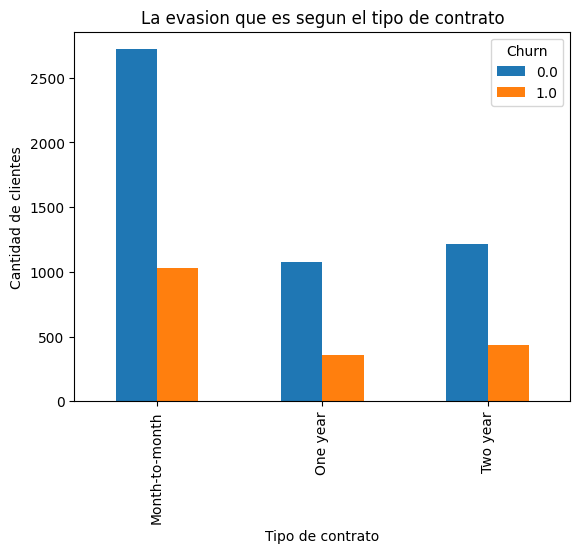

In [366]:
pd.crosstab(df['Contract'], df['Churn']).plot(kind='bar')

plt.title("La evasion que es segun el tipo de contrato")
plt.xlabel("Tipo de contrato")
plt.ylabel("Cantidad de clientes")

plt.show()

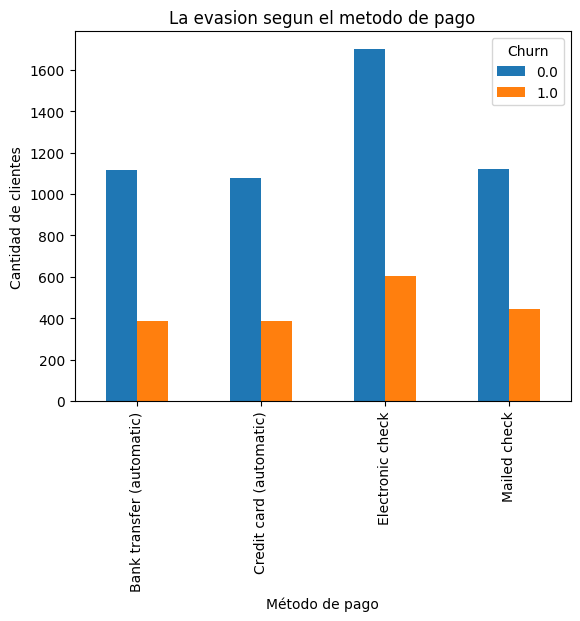

In [367]:
pd.crosstab(df['PaymentMethod'], df['Churn']).plot(kind='bar')
plt.title("La evasion segun el metodo de pago")
plt.xlabel("Método de pago")
plt.ylabel("Cantidad de clientes")

plt.show()

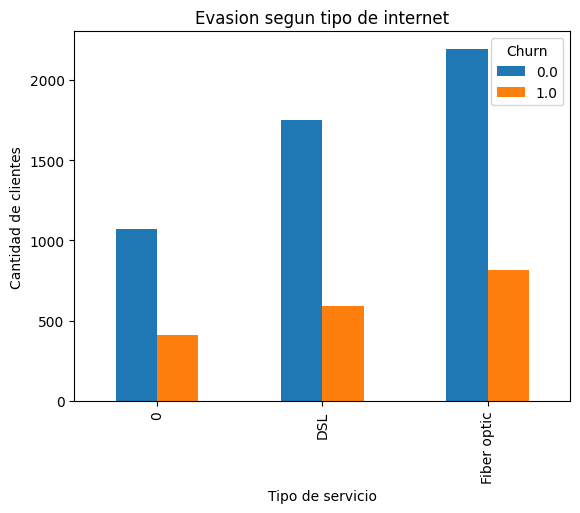

In [368]:
pd.crosstab(df['InternetService'], df['Churn']).plot(kind='bar')

plt.title("Evasion segun tipo de internet")
plt.xlabel("Tipo de servicio")
plt.ylabel("Cantidad de clientes")

plt.show()

### 4 - Conteo de evasión por variables numéricas

* En este paso, explora cómo las variables numéricas, como "total gastado" o "tiempo de contrato", se distribuyen entre los clientes que cancelaron (evasión) y los que no cancelaron.

* Este análisis ayuda a entender si ciertos valores numéricos están más asociados con la evasión, proporcionando insights sobre los factores que influyen en el comportamiento de los clientes.

In [369]:
import plotly.express as px

In [370]:
#Este grafico muestra cómo se distribuye el cargo mensual entre clientes que cancelaron y los que no.
##Si nos fijamos cuanto mas cara es la factura mensual es mas probable es que el cliente cancele el servicio. Los de azul pagan poco, pero son los mas fieles y tienden a quedarse.

fig = px.histogram(df,x="CargoMensual",color="Churn",nbins=30,title="Distribución del cargo mensual según evasión")
fig.show()

In [371]:
#Aqui estan los clientes que gastaron menos o más dinero tienden a cancelar.
fig = px.histogram(df,x="CargoTotal",color="Churn",nbins=30,title="Distribución del total gastado según evasión")
fig.show()

In [372]:
#Con este vemos si los clientes que cancelan tienen menos tiempo con la empresa.
fig = px.box(df,x="Churn",y="MesesCliente",title="Meses como cliente segun evasión")
fig.show()

In [373]:
import plotly.express as px

In [374]:
#Es el tipo de contrato vs churn
pd.crosstab(df['Contract'], df['Churn'])

Churn,0.0,1.0
Contract,,
Month-to-month,2720,1031
One year,1075,354
Two year,1214,436


In [375]:
print(df['MesesCliente'].mean())

32.37114865824223


In [376]:
pd.crosstab(df['PaymentMethod'], df['Churn'])

Churn,0.0,1.0
PaymentMethod,,
Bank transfer (automatic),1115,388
Credit card (automatic),1076,385
Electronic check,1700,602
Mailed check,1118,446


#📄Informe final

##Recomendaciones

###Lo que se recomiendo con todo esto es el empezar a fomentar el compromiso a largo plazo. Ya sea que la empresa ofresca descuentos o beneficios exclusivos a quienes decidan cambiarse a planes de uno o dos años. De esta forma, el cliente siente que ahorra dinero y la empresa asegura su permanencia.

###Siendo esto una forma en la que ambas partes ganen, siento otra cosas clave el poder facilitar el proceso de pago. Como el incentivar a los usuarios a registrar pagos automáticos en lugar de usar metodos manuales como el cheque electronico.

* Esto no solo es más comodo para el cliente, sino que reduce las cancelaciones por olvido o por tener que tomar la decisión de pagar cada mes. Y para los clientes que prefieren mantener su flexibilidad mes a mes, se pueden crear programas de fidelización. Al ofrecerles mejoras en su servicio o premios por su antigüedad.